In [2]:
import pandas as pd   
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("chatbot_intent.xlsx")
print(df.head(5))


  Message_ID  Message_Length  Word_Count  Has_Question  Has_Command  \
0    MSG0001              47          38             0            0   
1    MSG0002             173          20             1            1   
2    MSG0003              41          29             1            1   
3    MSG0004             189          47             1            0   
4    MSG0005              46          42             0            1   

   Has_Greeting  Has_Emoji  Punctuation_Count  Avg_Word_Length  \
0             0          1                  0             6.39   
1             0          1                  3             5.39   
2             0          1                  1             3.81   
3             1          1                  7             4.61   
4             1          0                  3             4.12   

   Sentiment_Polarity    Intent  
0               -0.24  Feedback  
1               -0.12  Question  
2               -0.06  Question  
3                0.54  Greeting  
4     

In [3]:
print("Shape of Dataset")
print(df.shape)

print("\nInformation")
print(df.info())

print("\n Missing values")
print(df.isnull().sum())

print("\n statics summery")
print(df.describe())

print("\n columns")
print(df.columns)


Shape of Dataset
(500, 11)

Information
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Message_ID          500 non-null    str    
 1   Message_Length      500 non-null    int64  
 2   Word_Count          500 non-null    int64  
 3   Has_Question        500 non-null    int64  
 4   Has_Command         500 non-null    int64  
 5   Has_Greeting        500 non-null    int64  
 6   Has_Emoji           500 non-null    int64  
 7   Punctuation_Count   500 non-null    int64  
 8   Avg_Word_Length     500 non-null    float64
 9   Sentiment_Polarity  500 non-null    float64
 10  Intent              500 non-null    str    
dtypes: float64(2), int64(7), str(2)
memory usage: 43.1 KB
None

 Missing values
Message_ID            0
Message_Length        0
Word_Count            0
Has_Question          0
Has_Command           0
Has_Greeting          0
Has_

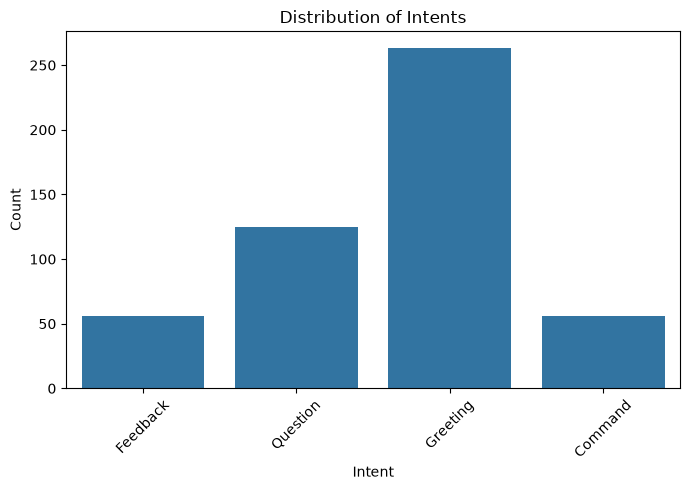

In [4]:
intent_count= df["Intent"].value_counts()
plt.figure(figsize=(7,5))
sns.countplot(x="Intent", data=df)
plt.title("Distribution of Intents")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

          Message_Length  Word_Count  Punctuation_Count
Intent                                                 
Command        92.589286   22.625000           4.464286
Feedback       94.107143   24.821429           4.464286
Greeting       91.779468   26.323194           4.612167
Question      109.888000   26.912000           4.744000


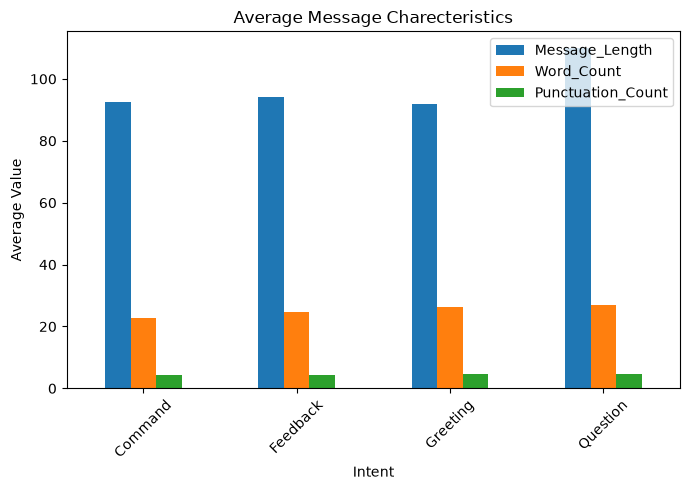

In [7]:
avg = df.groupby("Intent")[["Message_Length",
                            "Word_Count",
                            "Punctuation_Count"]].mean()
print(avg)
avg.plot(kind="bar",figsize=(7,5))
plt.title("Average Message Charecteristics")
plt.xlabel("Intent")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(round(2))

In [8]:
percentage= df.groupby("Intent")[["Has_Emoji",
                                  "Has_Greeting",
                                  "Has_Question",
                                  "Has_Command"]].mean()*100
print(percentage.round(2))

          Has_Emoji  Has_Greeting  Has_Question  Has_Command
Intent                                                      
Command       44.64           0.0          0.00       100.00
Feedback      37.50           0.0          0.00         0.00
Greeting      53.61         100.0         51.71        50.95
Question      59.20           0.0        100.00        52.80


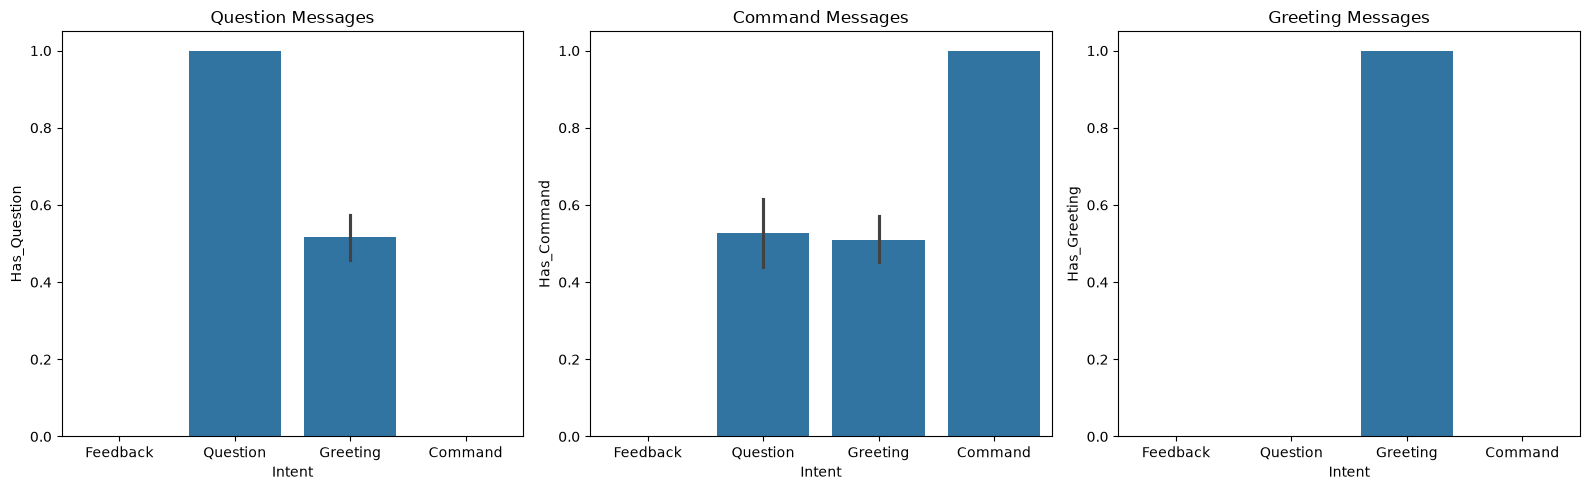

In [9]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

sns.barplot(data=df,
            x="Intent",
            y="Has_Question",
            ax=axes[0])

axes[0].set_title("Question Messages")

sns.barplot(data=df,
            x="Intent",
            y="Has_Command",
            ax=axes[1])

axes[1].set_title("Command Messages")

sns.barplot(data=df,
            x="Intent",
            y="Has_Greeting",
            ax=axes[2])

axes[2].set_title("Greeting Messages")

plt.tight_layout()

plt.show()

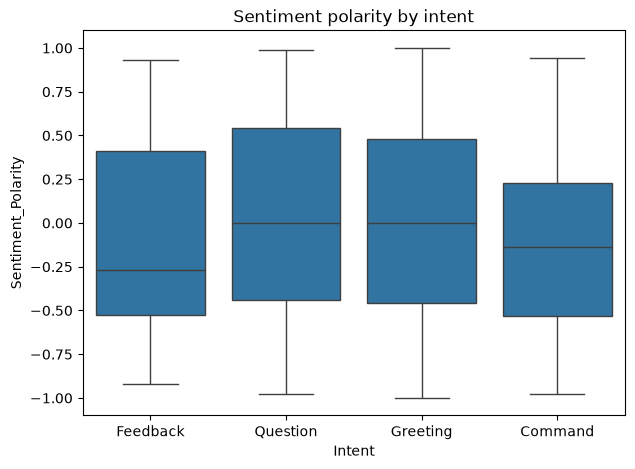

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data = df,
            x="Intent",
            y="Sentiment_Polarity")

plt.title("Sentiment polarity by intent")
plt.show()


In [11]:
print (df.groupby("Intent")["Sentiment_Polarity"].mean().round(2))

Intent
Command    -0.13
Feedback   -0.10
Greeting    0.00
Question    0.02
Name: Sentiment_Polarity, dtype: float64


          Avg_Word_Length  Punctuation_Count
Intent                                      
Command          5.324464           4.464286
Feedback         5.632500           4.464286
Greeting         5.385399           4.612167
Question         5.513120           4.744000


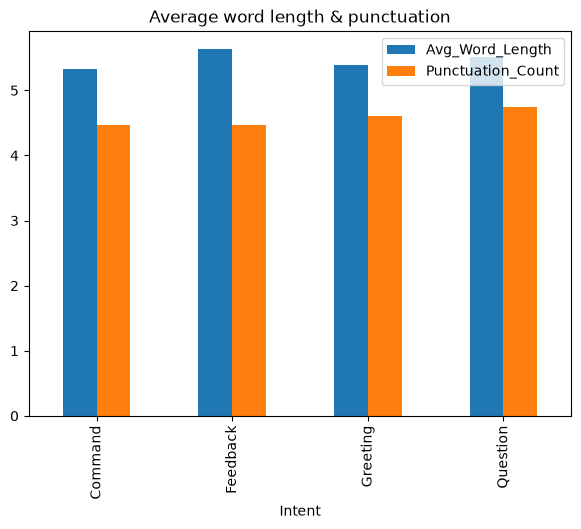

In [12]:
comparison = df.groupby("Intent")[["Avg_Word_Length",
                                   "Punctuation_Count"]].mean()
print(comparison)
comparison.plot(kind="bar",figsize=(7,5))
plt.title("Average word length & punctuation")
plt.show()


In [13]:
mean_table = df.groupby("Intent").mean(numeric_only=True)

print(mean_table.round(2))

          Message_Length  Word_Count  Has_Question  Has_Command  Has_Greeting  \
Intent                                                                          
Command            92.59       22.62          0.00         1.00           0.0   
Feedback           94.11       24.82          0.00         0.00           0.0   
Greeting           91.78       26.32          0.52         0.51           1.0   
Question          109.89       26.91          1.00         0.53           0.0   

          Has_Emoji  Punctuation_Count  Avg_Word_Length  Sentiment_Polarity  
Intent                                                                       
Command        0.45               4.46             5.32               -0.13  
Feedback       0.38               4.46             5.63               -0.10  
Greeting       0.54               4.61             5.39                0.00  
Question       0.59               4.74             5.51                0.02  


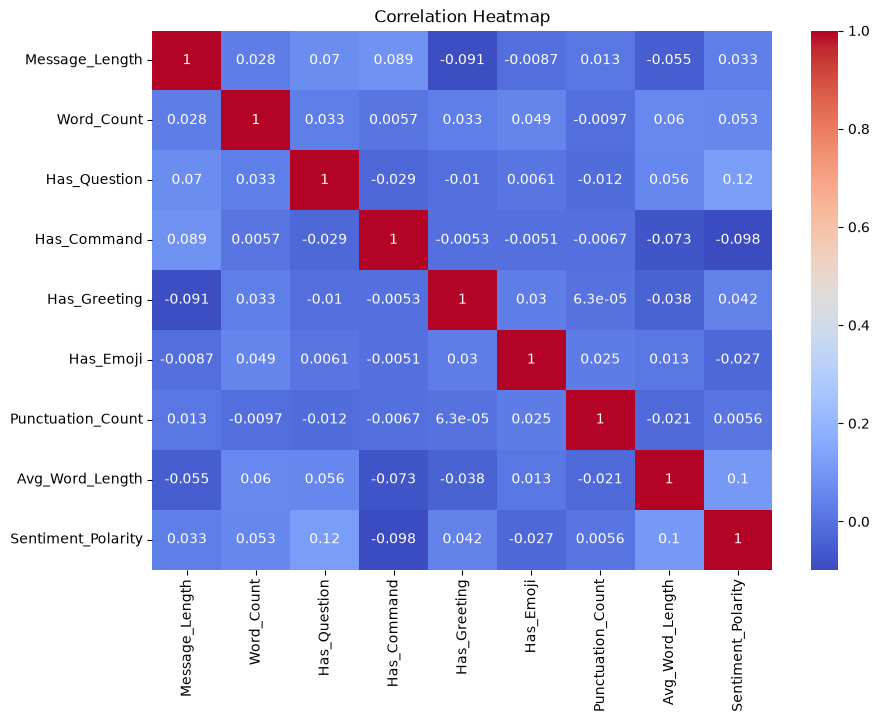

In [17]:
plt.figure(figsize=(10,7))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [5]:
Q1 = df["Message_Length"].quantile(.25)
Q3 = df["Message_Length"].quantile(.75)
IQR = Q3 - Q1
outlier = df[(df["Message_Length"]<Q1-1.5*IQR)|(df["Message_Length"]>Q3+1.5*IQR)]
print(outlier)             

Empty DataFrame
Columns: [Message_ID, Message_Length, Word_Count, Has_Question, Has_Command, Has_Greeting, Has_Emoji, Punctuation_Count, Avg_Word_Length, Sentiment_Polarity, Intent]
Index: []


In [9]:
df["Message_Category"] = pd.cut(
    df["Message_Length"],
    bins=[0, 30, 60, 1000],
    labels=["Short", "Medium", "Long"]
)

print(df["Message_Category"].value_counts())

Message_Category
Long      332
Medium     91
Short      77
Name: count, dtype: int64


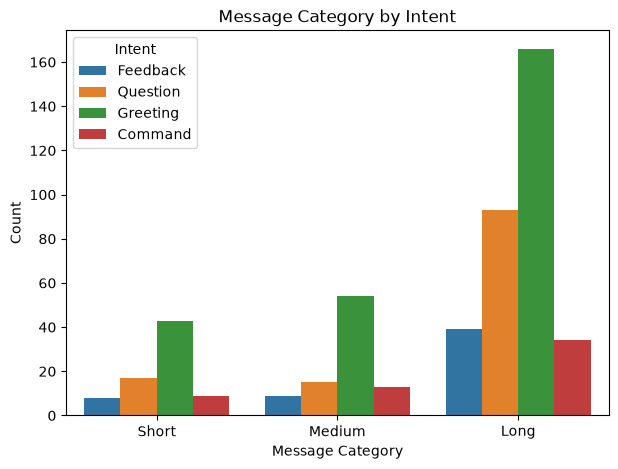

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Message_Category",
              hue="Intent")

plt.title("Message Category by Intent")
plt.xlabel("Message Category")
plt.ylabel("Count")
plt.show()
